<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Classification_Threshold_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Create a dataset with 20-000 total sample; out of these samples, 2% should be positive and the rest negative. Then train a small neural network, inspect its scores, select a threshold using validation data, and report the untouched test result.

For generation of the data use 'make_classification()' function from sickit learn data package with the following characteristics:

| Parameter | Definition|
|---|---|
| `n_samples=20_000` | Generate 20,000 observations. The underscore makes the number easier to read; `20_000` equals `20000`. |
| `n_features=20` | Give each observation 20 numerical features. |
| `n_informative=10` | Use 10 original features to construct patterns that distinguish the classes. |
| `n_redundant=5` | Add 5 features created as random linear combinations of the informative features. |
| `weights=[0.98, 0.02]` | Assign 98% of samples to class `0` and 2% to class `1`. |
| `flip_y=0` | Disable random reassignment of class labels. |
| `random_state=42` | Fix the random seed so the same call is reproducible in the same software environment. |


Use a minimum recall requirement of 80% and, among thresholds meeting it, chooses the one with the highest validation precision. That is an illustrative policy; in a real project, the required recall should come from the consequences and capacity of the application.

In [79]:
# Importing required libraries
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Activation, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,

    )

from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [58]:
# Fix the random seeds

SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [59]:
# Creating the data as required

n_feature = 20
x, y = make_classification(
    n_samples = 20_000,
    n_features = n_feature,
    n_informative = 10,
    n_redundant = 5,
    weights = [0.98, 0.02],
    flip_y = 0,
    random_state = SEED
)

print(y)

[0 0 0 ... 0 0 0]


In [60]:
# Splitting the data into training, validation and test sets

x_tr_val, x_test, y_tr_val, y_test = train_test_split(
                        x, y, test_size = 0.2,
                        stratify = y, random_state = SEED)


x_train, x_val, y_train, y_val = train_test_split(
                        x_tr_val, y_tr_val, test_size = 0.25,
                        stratify = y_tr_val, random_state = SEED)

In [61]:
# Now we see if the population of the positives is 2% across all parts

print(np.mean(y_train), np.mean(y_val), np.mean(y_test))

0.02 0.02 0.02


In [62]:
# Scaling the data through the scaling parameters attained from the training set

scaler = StandardScaler()
scaler.fit_transform(x_train)
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [63]:
# Creating the architecture of the model

model = Sequential([
    Input(shape = (n_feature,)),

    Dense(100, activation = 'relu', kernel_initializer = 'he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(50, activation = 'relu', kernel_initializer = 'he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(25, activation = 'relu', kernel_initializer = 'he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation = 'sigmoid')

]
)



In [64]:
# Compiling the model

model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'binary_crossentropy'
)


In [65]:

# Early stopping criteria
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True,
    verbose = 1,
    mode = 'min',
    min_delta = 0,

    )


# Model to be saved
model_checkpoint = ModelCheckpoint(
    'model.keras',
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)


# Adjusting the learning rate
lr_reduce = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.1,
    patience = 5,
    verbose = 1,
    mode = 'min',
    min_delta = 0
)





In [66]:
# Fitting the model

HIST = model.fit(x_train, y_train,
          validation_data = (x_val, y_val),
          epochs = 200,
          callbacks = [early_stopping, model_checkpoint, lr_reduce],
          verbose = 1,
          batch_size = 200,
          shuffle = True,

)

Epoch 1/200
49/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9075
Epoch 1: val_loss improved from None to 0.95931, saving model to model.keras

Epoch 1: finished saving model to model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.8854 - val_loss: 0.9593 - learning_rate: 1.0000e-04
Epoch 2/200
48/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8510
Epoch 2: val_loss improved from 0.95931 to 0.70038, saving model to model.keras

Epoch 2: finished saving model to model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8363 - val_loss: 0.7004 - learning_rate: 1.0000e-04
Epoch 3/200
52/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8154
Epoch 3: val_loss improved from 0.70038 to 0.61159, saving model to model.keras

Epoch 3: finished saving model to model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8011 - val_loss: 0.6116 - learning_rate: 1.0000e-04
Epoch 4/200
53/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7771
Epoch 4: val_loss improved from 0.61159 to 0.57076, sa

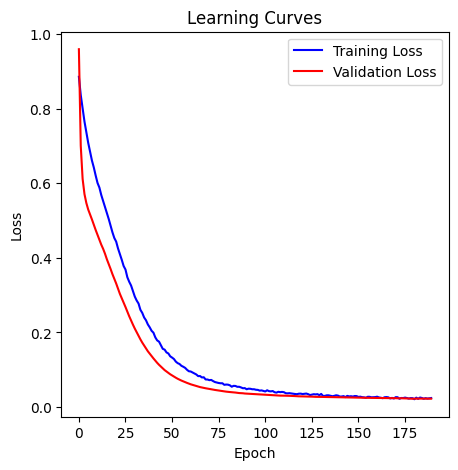

In [67]:
# plotting the learning curves

plt.figure(figsize = (5, 5))
plt.plot(HIST.history['loss'], label = 'Training Loss', color = 'blue')
plt.plot(HIST.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.show()

In [74]:
val_scores = model.predict(x_val).ravel()


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [76]:
print('validation average precision:',
      average_precision_score(y_val, val_scores))

print('validation roc auc:',
      roc_auc_score(y_val, val_scores))

validation average precision: 0.907389796654652
validation roc auc: 0.9945982142857143
